# 06 — Simulation twin (L3): แสง · ความร้อน · CO₂ · การเติบโต · what-if (แสง, ชนิดผัก)

ทุกแบบจำลองเป็นเมธอดของ **`DigitalTwin`**: `light()` · `heat_balance()` · `daily_energy()` · `fit_co2()` · `co2_balance()` · `whatif_light()` · `crop_mix()` · `crop_mix_3d()` — สมการอยู่ใน `pfal_twin/models.py` และ**พารามิเตอร์ทุกตัวมีที่มา** (`twin.params.to_frame()`; `ASSUMED` = ต้องวัด/ยืนยัน)

> ⚠️ นี่คือโครงแบบจำลอง — ก่อนใช้ตัดสินใจต้อง calibrate: จำนวน LED bar/ชั้น, efficacy (วัด PPFD), อุณหภูมิฝั่งร้านกาแฟ, COP แอร์, ค่าไฟ, น้ำหนักผักตอนเก็บ

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


In [2]:
from pfal_twin.twin import DigitalTwin
from pfal_twin import models as M
twin = DigitalTwin.load(); p = twin.params
bright = {i: twin.data[f"gc1.currentStageBrightness{i}"].dropna().mode().iloc[0] for i in range(1, 5)}
print(f"photoperiod from gc1.led duty: {p.photoperiod_h:.1f} h/day | gc1 brightness ch1-4 (mode): {bright} → model uses dim {p.dim_pct:.0f} % | room mean {p.setpoint_t:.1f} °C")
display(p.to_frame())

photoperiod from gc1.led duty: 9.4 h/day | gc1 brightness ch1-4 (mode): {1: np.float64(0.0), 2: np.float64(22.0), 3: np.float64(0.0), 4: np.float64(0.0)} → model uses dim 100 % | room mean 24.3 °C


,value,source
led_bars_per_tier,8.000000,photos (count on site)
led_w_per_bar,42.000000,design spec p.4
led_tiers,4.000000,site
nursery_bars,8.000000,photos
led_efficacy_umol_per_j,2.300000,ASSUMED - measure PPFD
canopy_fraction,0.850000,ASSUMED
photoperiod_h,9.370700,gc1.led duty (data)
dim_pct,100.000000,gc1.currentStageBrightness
wall_u,0.600000,material (design)
roof_u,0.500000,material (design)


## 1. แสง — PPFD และ DLI ต่อชั้นจากกำลังไฟ LED (ใช้จนกว่าจะมี PPFD map จริง)

In [3]:
rows = [dict(dim_pct=d, **{k: round(v, 1) for k, v in twin.light(dim_pct=d).items()}, DLI_16h=round(twin.light(dim_pct=d, photoperiod_h=16)["dli"], 1)) for d in (100, 80, 60, 40)]
display(pd.DataFrame(rows).set_index("dim_pct")); print("target DLI for lettuce: 12–17 mol/m²/d; tray area %.2f m²" % twin.rack_area)

,ppfd,dli,led_kw,DLI_16h
dim_pct,,,,
100,116.3,3.9,1.3,6.7
80,93.1,3.1,1.1,5.4
60,69.8,2.4,0.8,4.0
40,46.5,1.6,0.5,2.7


target DLI for lettuce: 12–17 mol/m²/d; tray area 5.65 m²


ด้วย 8 bar × 42 W ต่อชั้น PPFD ~120 µmol/m²/s ที่ 100 % — ต่ำกว่าช่วงแนะนำผักสลัด (150–250) → ถ้าวัดจริงได้สูงกว่านี้แปลว่า efficacy สูงกว่าที่สมมติหรือ bar มากกว่า 8 — เหตุผลที่ต้องวัด PPFD

## 2. ความร้อน — สมดุลพลังงานสถานะคงตัวของห้องปลูก (LED, อุปกรณ์, ผนัง/หลังคา/หน้าต่าง, อากาศรั่ว vs กำลังแอร์)

,lights ON (W),lights OFF (W)
"long wall (AC side, Y=W) -> outside",95.0,55.0
long wall (Y=0) minus windows -> outside/cafe,26.0,26.0
windows -> cafe,40.0,40.0
far wall (X=L) -> outside,40.0,23.0
partition (X=0) -> anteroom,19.0,12.0
roof -> outside,93.0,54.0
floor -> ground,18.0,18.0
infiltration,48.0,28.0
LED (growing tiers),1344.0,0.0
LED (nursery tier),336.0,0.0


,per day
LED,15.7
AC,14.6
fans + pumps + dehumidifier,20.9
total,51.3
THB/day,230.7
cooling load lit (kW),2.9
cooling load dark (kW),1.1


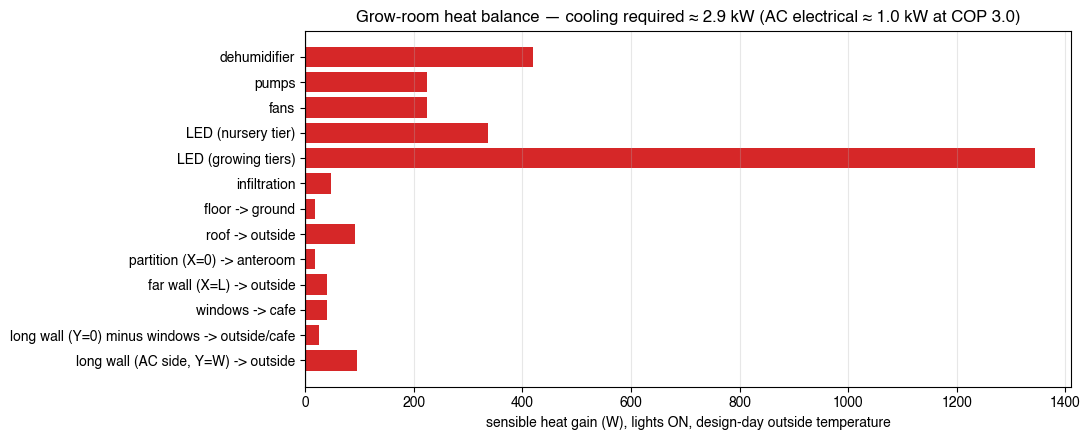

In [4]:
q_on, q_off = twin.heat_balance(led_on=True), twin.heat_balance(led_on=False)
heat = pd.DataFrame({"lights ON (W)": q_on, "lights OFF (W)": q_off}).round(0); display(heat)
fig, ax = plt.subplots(figsize=(11, 4.5))
items = [k for k in q_on if k not in ("cooling required", "AC electrical (at COP)", "AC capacity (electrical, design)")]
ax.barh(items, [q_on[k] for k in items], color=["#d62728" if q_on[k] > 0 else "#1f77b4" for k in items]); ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("sensible heat gain (W), lights ON, design-day outside temperature"); ax.set_title(f"Grow-room heat balance — cooling required ≈ {q_on['cooling required']/1000:.1f} kW (AC electrical ≈ {q_on['AC electrical (at COP)']/1000:.1f} kW at COP {p.ac_cop})")
ax.grid(alpha=.3, axis="x"); fig.tight_layout(); fig.savefig(FIG / "06_heat_balance.png", dpi=150)
pd.Series(twin.daily_energy()).round(1).to_frame("per day")

LED เป็นภาระความร้อนหลัก (~55 %) รองลงมาคือเครื่องลดความชื้น/พัดลม/ปั๊ม ส่วนผนัง+หน้าต่างรวมกันไม่ถึง 15 % — what-if เรื่องแสงกระทบค่าไฟแอร์โดยตรง

## 3. CO₂ — fit อัตรารั่ว (air exchange) จากช่วงที่ CO₂ ลดลงเองตอนไฟปิดและไม่มีการจ่าย แล้วคำนวณสมดุล

25 decay segments | λ median 0.079 h⁻¹ (IQR 0.062–0.118) → ~0.08 air changes per hour


volume_m3               55.30
leakage_g_h              3.80
canopy_uptake_g_h       20.90
total_g_h               24.70
kg_per_day_lit_hours     0.23
cylinder_6kg_days       25.90
dtype: float64

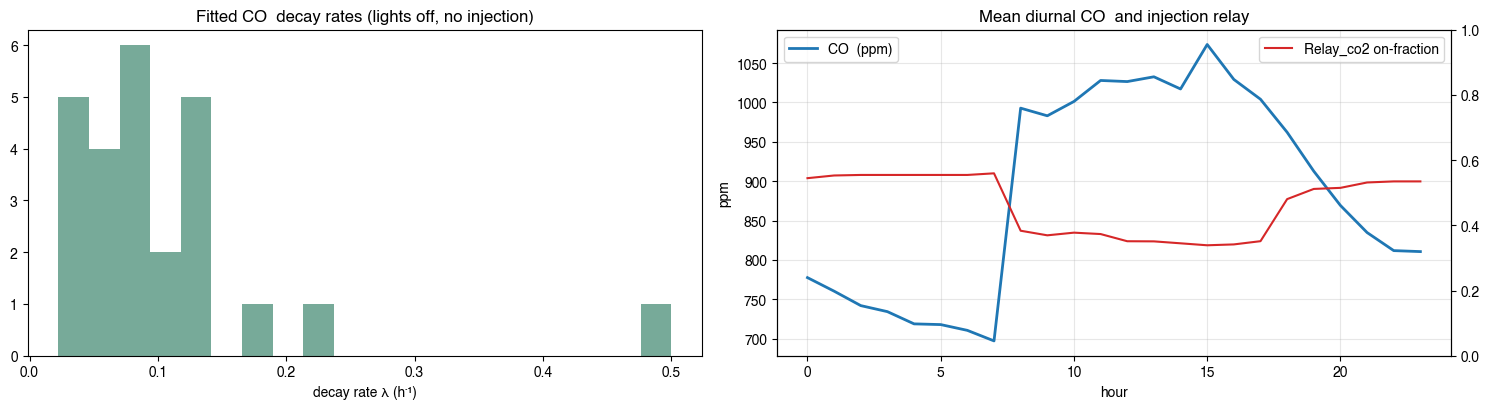

In [5]:
fits = twin.fit_co2(); lam = p.infiltration_ach
print(f"{len(fits)} decay segments | λ median {lam:.3f} h⁻¹ (IQR {fits.lam_per_h.quantile(.25):.3f}–{fits.lam_per_h.quantile(.75):.3f}) → ~{lam:.2f} air changes per hour")
w = twin.data
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
axes[0].hist(fits.lam_per_h.clip(0, 0.5), bins=20, color="#7a9"); axes[0].set_xlabel("decay rate λ (h⁻¹)"); axes[0].set_title("Fitted CO₂ decay rates (lights off, no injection)")
c = w["co2.CO2"].groupby(w.index.hour).mean(); r = w["co2.Relay_co2"].groupby(w.index.hour).mean()
axes[1].plot(c.index, c, lw=2, label="CO₂ (ppm)"); ax2 = axes[1].twinx(); ax2.plot(r.index, r, color="#d62728", lw=1.5, label="Relay_co2 on-fraction"); ax2.set_ylim(0, 1)
axes[1].set_xlabel("hour"); axes[1].set_ylabel("ppm"); axes[1].set_title("Mean diurnal CO₂ and injection relay"); axes[1].grid(alpha=.3); axes[1].legend(loc="upper left"); ax2.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "06_co2_decay.png", dpi=150)
pd.Series(twin.co2_balance(c_target=900))

λ ≈ 0.08 h⁻¹ = ห้องรั่วน้อยมาก → รักษา 900 ppm ใช้ CO₂ ระดับสิบกรัม/ชม. ถัง 6 กก. ใช้ได้ ~1 เดือน — ควรเทียบกับบันทึกการเติมถังจริง

## 4. What-if แสง — photoperiod × ความสว่าง → PPFD/DLI, kWh/วัน, บาท/วัน, ภาระแอร์, วันเก็บเกี่ยว (schematic)

,photoperiod_h,dim_pct,PPFD,DLI,kWh_LED,kWh_AC,kWh_total,THB_day,cooling_lit_kW,days_to_150g
0,12,60,70,3.0,12.1,13.3,46.3,208,2.22,62.1
1,12,80,93,4.0,16.1,14.6,51.7,232,2.56,50.7
2,12,100,116,5.0,20.2,16.0,57.0,257,2.89,43.4
3,14,60,70,3.5,14.1,14.0,49.0,221,2.22,55.7
4,14,80,93,4.7,18.8,15.6,55.3,249,2.56,45.5
5,14,100,116,5.9,23.5,17.2,61.6,277,2.89,39.0
6,16,60,70,4.0,16.1,14.8,51.8,233,2.22,50.7
7,16,80,93,5.4,21.5,16.6,59.0,265,2.56,41.5
8,16,100,116,6.7,26.9,18.4,66.1,298,2.89,35.5
9,18,60,70,4.5,18.1,15.5,54.6,246,2.22,46.7


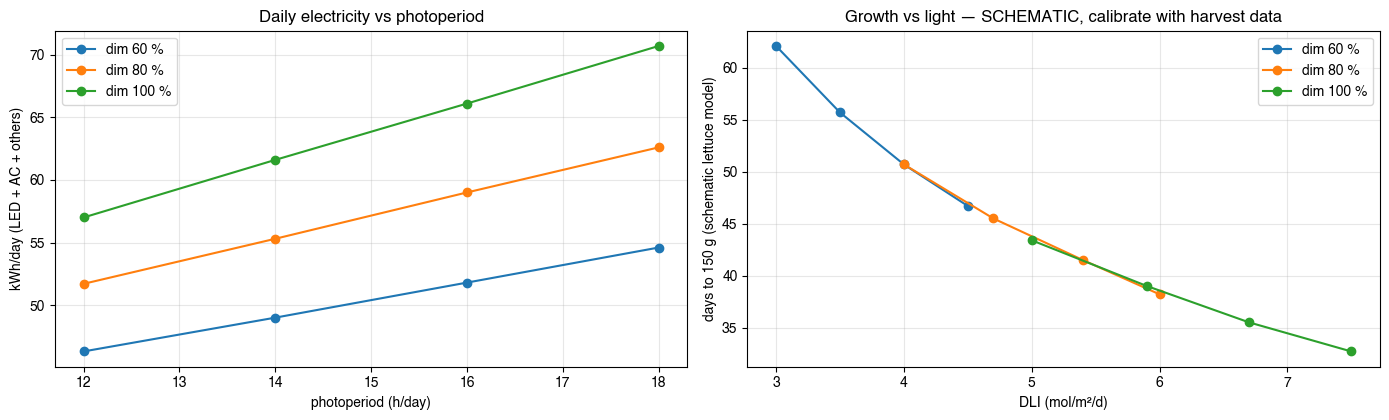

In [6]:
wi = twin.whatif_light(); wi.to_csv(io.PROCESSED / "whatif_light_energy.csv", index=False); display(wi)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for dm in wi.dim_pct.unique():
    s = wi[wi.dim_pct == dm]; axes[0].plot(s.photoperiod_h, s.kWh_total, "-o", label=f"dim {dm} %"); axes[1].plot(s.DLI, s.days_to_150g, "-o", label=f"dim {dm} %")
axes[0].set_xlabel("photoperiod (h/day)"); axes[0].set_ylabel("kWh/day (LED + AC + others)"); axes[0].set_title("Daily electricity vs photoperiod"); axes[0].grid(alpha=.3); axes[0].legend()
axes[1].set_xlabel("DLI (mol/m²/d)"); axes[1].set_ylabel("days to 150 g (schematic lettuce model)"); axes[1].set_title("Growth vs light — SCHEMATIC, calibrate with harvest data"); axes[1].grid(alpha=.3); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG / "06_whatif.png", dpi=150)

## 5. What-if ชนิดผัก — สัดส่วนผักบน 700 หลุมของชั้น 2–5 → ผังรายหลุม (2D/3D) + ผลผลิต/รายได้/ความต้องการแสง
- 700 หลุม (ผู้ใช้ 14 ก.ย.) = 175/ชั้น → กริด 25 × 7 (จำนวนแถวสมมติ — นับหน้างานแล้วแก้ `rows=`)
- แคตตาล็อกผัก `models.CROPS` เป็นค่าทั่วไป ต้องแทนด้วยบันทึกของฟาร์ม; นโยบาย `blocks` (บล็อกต่อเนื่องทีละชั้น) / `per_tier` (ทุกชั้นผสมเท่ากัน)

In [7]:
pd.DataFrame(M.CROPS).T.drop(columns="color")

,days,fw_g,dli,price_thb_kg,group
green oak,35,150,13,120,lettuce
red oak,38,140,14,140,lettuce
butterhead,40,180,13,130,lettuce
cos/romaine,45,220,15,110,lettuce
frillice,42,160,15,150,lettuce
kale,50,200,16,180,brassica
rocket,28,60,12,250,brassica
basil,40,80,16,200,herb
coriander,32,40,12,180,herb
empty,0,0,0,0,-


In [8]:
MIX = {"green oak": 40, "red oak": 30, "butterhead": 20, "basil": 10}      # percent — edit freely
assign, summary, fig3d = twin.crop_mix(MIX, policy="blocks", view="3d", name="06_crop_mix_3d")     # 3-D: one marker per hole, click legend to toggle crops
assign.to_csv(io.PROCESSED / "crop_mix_assignment.csv", index=False); display(summary)

full-window version: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/06_crop_mix_3d.html   (open in a browser)


,holes,share_pct,days_to_harvest,plant_fw_g,kg_per_cycle,cycles_per_year,kg_per_year,THB_per_year,DLI_need,DLI_available,light_ok
crop,,,,,,,,,,,
basil,70.0,10.0,40.0,80.0,5.6,9.1,51.0,10220.0,16.0,6.7,short by 9.3
butterhead,140.0,20.0,40.0,180.0,25.2,9.1,230.0,29894.0,13.0,6.7,short by 6.3
green oak,280.0,40.0,35.0,150.0,42.0,10.4,438.0,52560.0,13.0,6.7,short by 6.3
red oak,210.0,30.0,38.0,140.0,29.4,9.6,282.0,39535.0,14.0,6.7,short by 7.3
TOTAL,700.0,100.0,NaN,NaN,NaN,NaN,1001.0,132209.0,NaN,NaN,NaN


แบบ 2 มิติ (รายหลุมต่อชั้น) สำหรับใส่บทความ และนโยบาย `per_tier` เปรียบเทียบ

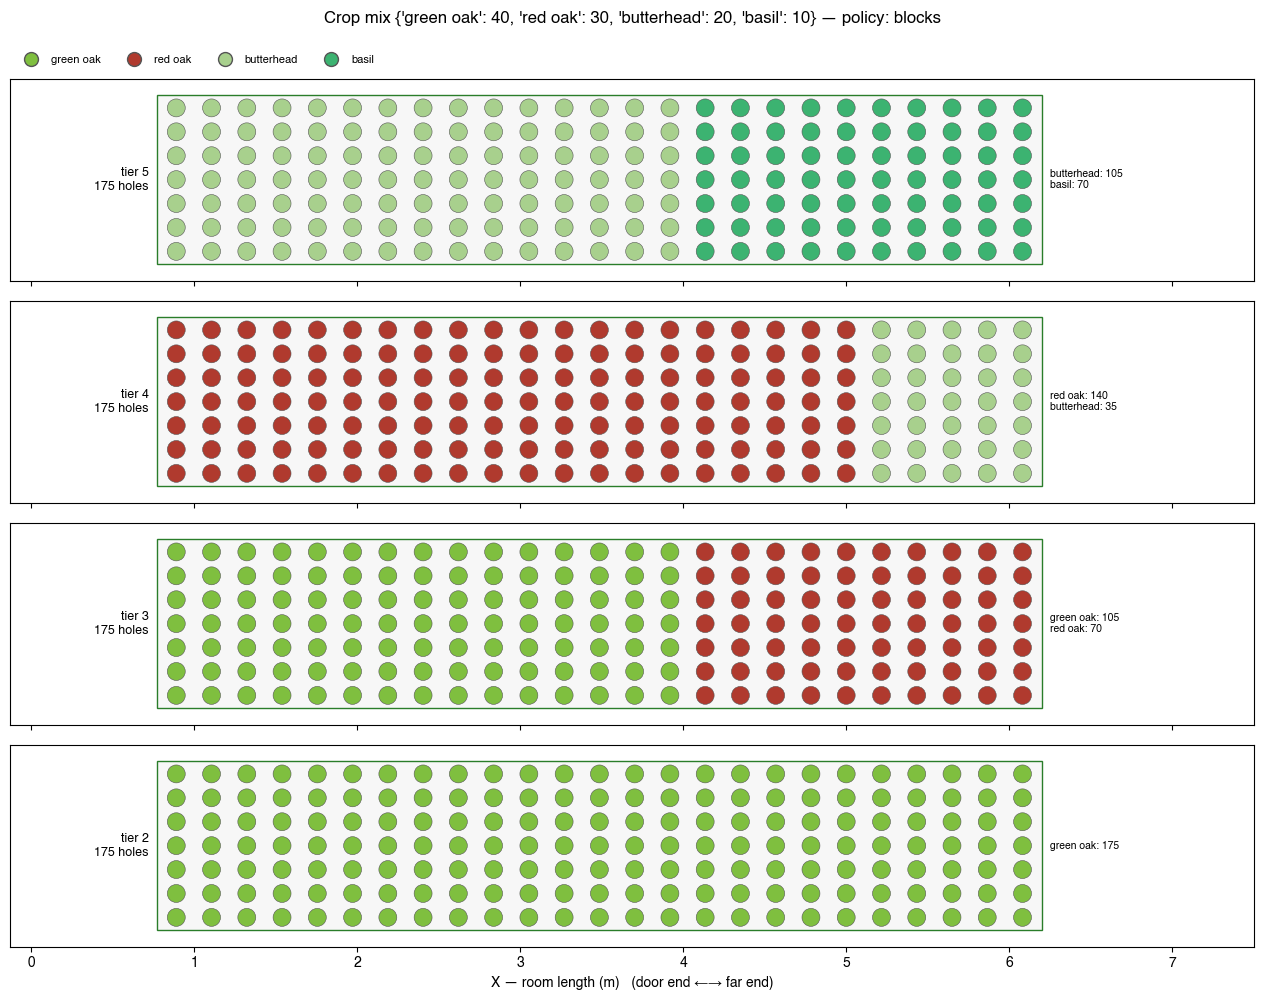

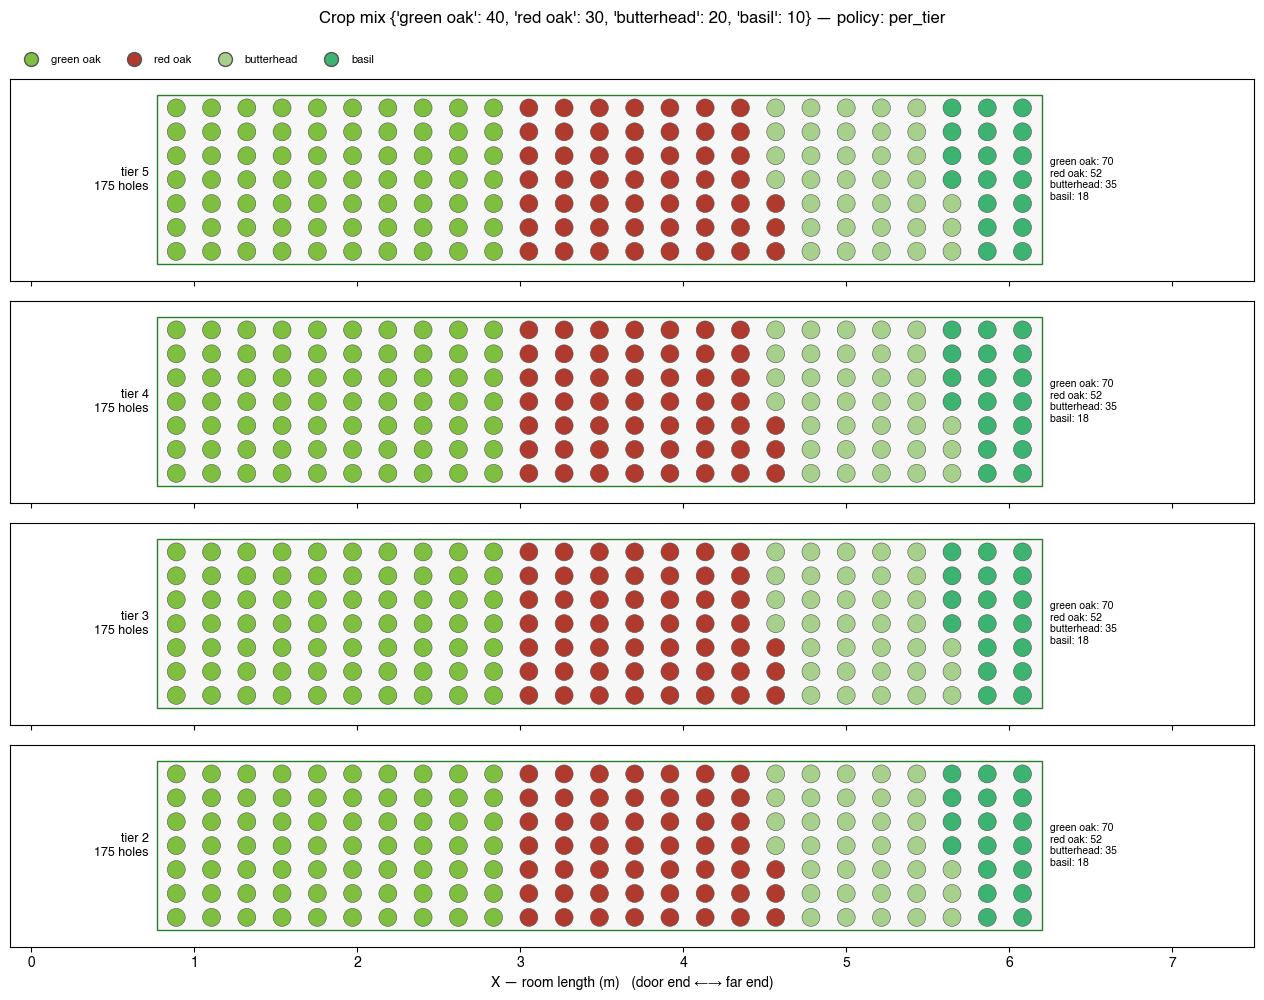

In [9]:
_ = twin.crop_mix(MIX, policy="blocks", view="2d", path=FIG / "06_crop_mix_plan.png")
_ = twin.crop_mix(MIX, policy="per_tier", view="2d", path=FIG / "06_crop_mix_plan_per_tier.png")

### โต้ตอบ: เลื่อน % ของแต่ละชนิด (normalise ให้เอง)

In [10]:
import ipywidgets as widgets
crops_ui = [c for c in M.CROPS if c != "empty"]
sliders = {c: widgets.IntSlider(value=MIX.get(c, 0), min=0, max=100, step=5, description=c, continuous_update=False, layout=widgets.Layout(width="45%")) for c in crops_ui}
policy_ui = widgets.ToggleButtons(options=["blocks", "per_tier"], description="policy")
def _run(policy, **pct):
    mix = {k: v for k, v in pct.items() if v > 0} or {"empty": 100}
    a, s, f = twin.crop_mix(mix, policy=policy, view="3d"); display(s)
widgets.interact(_run, policy=policy_ui, **sliders);

interactive(children=(ToggleButtons(description='policy', options=('blocks', 'per_tier'), value='blocks'), Int…

## 6. Sanity check กับข้อมูลจริง
- ห้องปลูก ~24 °C คงที่ (แกว่ง 1–1.6 °C) → แอร์ 2 ตัวรับภาระ ~3 kW ได้สบาย ยกเว้นวันที่ระบบดับ (9–12 ก.ย. 2026 ห้องขึ้นถึง 28–31 °C)
- `gc1.led` duty ≈ 9 ชม./วัน (น้อยกว่า 16 ชม. ที่มักใช้) และ `currentStageBrightness1–4` = 0/22/0/0 % → ต้องเช็กความหมายของ key เหล่านี้กับ Civic
- CO₂ กลางวัน ~500–700 ppm พร้อม relay ทำงาน แต่ไม่ถึง 900 ppm → ดู setpoint ใน CO₂ controller

## ข้อมูลที่ต้องเก็บเพื่อ calibrate (ลำดับความสำคัญ)
1. **PPFD map** ทุกชั้น (grid 3×3) → efficacy, canopy_fraction · 2. นับ LED bar/ชั้น + วัตต์จริง · 3. ตาราง photoperiod/dim + ความหมาย `led`/`currentStageBrightness` · 4. BTU/รุ่นแอร์ + กระแสจริง → COP; T ฝั่งร้านกาแฟ · 5. น้ำหนักผักตอนเก็บ + วันปลูก → growth model · 6. บันทึกเติมถัง CO₂